# Phase 2 — Stress Test: Intermittent and Low-SNR Conditions

Simulates two challenging conditions the DroneRF dataset does not naturally contain,
directly addressing Reviewer 3's generalization concern.

## Experiment 1 — Amplitude scaling (low effective SNR)
Signal chunks scaled by α ∈ {1.0, 0.5, 0.25, 0.1, 0.05} → {0, −6, −12, −20, −26} dB.
Background threshold fixed from clean data. Shows where cascade Stage 1 stops triggering.

## Experiment 2 — Duty cycle masking (intermittent transmission)
Each signal chunk independently kept (prob = duty cycle) or replaced by zeros.
Duty cycle ∈ {1.0, 0.5, 0.25, 0.10}. Shows cascade degrading when bursts < mbl=50.

**Memory:** chunks loaded one file at a time, never held in full across segments.  
**Expected runtime:** ~30 min per experiment.  
All outputs → `results/review_1/`

In [ ]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from glob import glob
from pathlib import Path
from dotenv import load_dotenv
from sklearn.metrics import roc_curve, auc
from tqdm import tqdm

ROOT = Path().resolve().parents[2]
sys.path.insert(0, str(ROOT / "src"))

from rfml_uav.drone_rf.consts import BUI, FS_HZ
from rfml_uav.drone_rf.utils import get_segment_count, get_binary_label
from rfml_uav.signal_detection.methods import energy_detector, wavelet_detector, cyclo_detector
from rfml_uav.signal_detection.cascade import aggregate_bursts

load_dotenv()
CHUNKED_PATH = Path(os.getenv("DATA_PATH")) / "chunked"
OUT = ROOT / "results" / "review_1"
OUT.mkdir(parents=True, exist_ok=True)

BG_BUI     = "00000"
FIXED_PFA  = 0.05
FIXED_MBL  = 50
FIXED_NFFT = 512

SIGNAL_BUIS = [b for b in BUI if get_binary_label(b) == 1]
NOISE_BUIS  = [b for b in BUI if get_binary_label(b) == 0]

METHODS  = ["Energy", "Wavelet", "Cyclo", "Cascade"]
COLORS   = {"Energy": "#1f77b4", "Wavelet": "#ff7f0e", "Cyclo": "#2ca02c", "Cascade": "#d62728"}
MARKERS  = {"Energy": "o", "Wavelet": "s", "Cyclo": "^", "Cascade": "D"}

print(f"ROOT         : {ROOT}")
print(f"CHUNKED_PATH : {CHUNKED_PATH}")
print(f"Signal BUIs  : {SIGNAL_BUIS}")
print(f"Noise BUIs   : {NOISE_BUIS}")

ROOT         : /home/ivan/work/ml/rfml-uav
CHUNKED_PATH : /home/ivan/work/ml/rfml-uav/data/drone-rf/chunked
Signal BUIs  : ['10000', '10001', '10010', '10011', '10100', '10101', '10110', '10111', '11000']
Noise BUIs   : ['00000']


In [2]:
print("Estimating energy threshold from clean background...")
bg_scores = []
for seg in range(get_segment_count(BG_BUI)):
    for fp in sorted(glob(str(CHUNKED_PATH / f"{BG_BUI}*_{seg}.npz"))):
        chunks = np.load(fp)["arr_0"]
        bg_scores.extend(energy_detector(x) for x in chunks)

thr_energy = float(np.percentile(bg_scores, 100 * (1 - FIXED_PFA)))
print(f"thr_energy = {thr_energy:.4f}  (Pfa = {FIXED_PFA})")

Estimating energy threshold from clean background...
thr_energy = 14.7695  (Pfa = 0.05)


## Core evaluation helper

`evaluate_with_transform` streams data one `.npz` file at a time.
The `transform_fn` is applied to each chunk array immediately after loading;
raw data is discarded before the next file is read.

In [3]:
def duration_constrained_score(scores, min_duration=0.10):
    k = max(1, int(np.ceil(min_duration / (4000 / FS_HZ))))
    if len(scores) <= k:
        return float(np.mean(scores))
    return float(np.mean(np.sort(scores)[-k:]))


def evaluate_with_transform(transform_fn, thr, mbl, nfft, desc=""):
    """
    Full segment-level evaluation for all four detectors.
    transform_fn(chunks: ndarray) -> ndarray  applied per-file to signal chunks.
    Noise segments always use raw chunks (no transform).
    Memory: one .npz file in RAM at a time.
    """
    seg_scores = {m: [] for m in METHODS}
    seg_labels = []

    all_buis = [(b, 1) for b in SIGNAL_BUIS] + [(b, 0) for b in NOISE_BUIS]

    for bui, label in tqdm(all_buis, desc=desc):
        for seg in range(get_segment_count(bui)):
            files = sorted(glob(str(CHUNKED_PATH / f"{bui}*_{seg}.npz")))
            if not files:
                continue

            e_sc, w_sc, c_sc, casc_scores = [], [], [], []

            for fp in files:
                raw = np.load(fp)["arr_0"]
                chunks = transform_fn(raw) if label == 1 else raw

                # compute energy once per chunk, reuse for both score and cascade decision
                e_vals = [energy_detector(x) for x in chunks]
                e_sc.extend(e_vals)
                w_sc.extend(wavelet_detector(x) for x in chunks)
                c_sc.extend(cyclo_detector(x, fs=FS_HZ) for x in chunks)

                bursts = aggregate_bursts([e >= thr for e in e_vals], min_len=mbl)
                if bursts:
                    casc_scores.append(max(
                        cyclo_detector(np.concatenate(chunks[b0:b1]), fs=FS_HZ, Nfft=nfft)
                        for b0, b1 in bursts
                    ))

            seg_scores["Energy"].append(duration_constrained_score(e_sc))
            seg_scores["Wavelet"].append(duration_constrained_score(w_sc))
            seg_scores["Cyclo"].append(duration_constrained_score(c_sc))
            seg_scores["Cascade"].append(max(casc_scores) if casc_scores else 0.0)
            seg_labels.append(label)

    seg_labels = np.array(seg_labels)
    results = {}
    for method in METHODS:
        s = np.array(seg_scores[method])
        fpr, tpr, _ = roc_curve(seg_labels, s)
        roc_auc = auc(fpr, tpr)
        ok = np.where(fpr <= FIXED_PFA)[0]
        i  = ok[np.argmax(tpr[ok])] if len(ok) else np.argmin(fpr)
        results[method] = {"Pd": float(tpr[i]), "AUC": roc_auc}
    return results


def build_row(param_key, param_val, results):
    row = {param_key: param_val}
    for method, m in results.items():
        row[f"{method}_Pd"]  = m["Pd"]
        row[f"{method}_AUC"] = m["AUC"]
    return row

---
## Experiment 1 — Amplitude Scaling (Low Effective SNR)

| α | dB reduction |
|---|---|
| 1.00 | 0 dB (baseline) |
| 0.50 | −6 dB |
| 0.25 | −12 dB |
| 0.10 | −20 dB |
| 0.05 | −26 dB |

**Expected runtime: ~30 min**

In [4]:
ALPHA_VALS = [1.0, 0.5, 0.25, 0.10, 0.05]
alpha_records = []

for alpha in ALPHA_VALS:
    db = 20 * np.log10(alpha)
    print(f"\nα={alpha}  ({db:+.0f} dB)")

    results = evaluate_with_transform(
        transform_fn=lambda chunks, a=alpha: chunks * a,
        thr=thr_energy, mbl=FIXED_MBL, nfft=FIXED_NFFT,
        desc=f"α={alpha} ({db:+.0f} dB)",
    )
    for method, m in results.items():
        print(f"  {method:10s}: Pd={m['Pd']:.3f}  AUC={m['AUC']:.3f}")

    alpha_records.append(build_row("alpha", alpha, results))

df_alpha = pd.DataFrame(alpha_records)
df_alpha["db_reduction"] = 20 * np.log10(df_alpha["alpha"])
df_alpha.to_csv(OUT / "stress_amplitude.csv", index=False)
print(f"\nSaved: {OUT / 'stress_amplitude.csv'}")
print(df_alpha.to_string(index=False))


α=1.0  (+0 dB)


α=1.0 (+0 dB): 100%|██████████| 10/10 [12:12<00:00, 73.26s/it]


  Energy    : Pd=1.000  AUC=1.000
  Wavelet   : Pd=1.000  AUC=1.000
  Cyclo     : Pd=1.000  AUC=1.000
  Cascade   : Pd=1.000  AUC=1.000

α=0.5  (-6 dB)


α=0.5 (-6 dB): 100%|██████████| 10/10 [12:04<00:00, 72.50s/it]


  Energy    : Pd=1.000  AUC=1.000
  Wavelet   : Pd=1.000  AUC=1.000
  Cyclo     : Pd=1.000  AUC=1.000
  Cascade   : Pd=1.000  AUC=1.000

α=0.25  (-12 dB)


...

  Energy    : Pd=1.000  AUC=1.000
  Wavelet   : Pd=1.000  AUC=1.000
  Cyclo     : Pd=1.000  AUC=1.000
  Cascade   : Pd=1.000  AUC=1.000

α=0.1  (-20 dB)


α=0.1 (-20 dB): 100%|██████████| 10/10 [11:56<00:00, 71.68s/it]


  Energy    : Pd=0.995  AUC=0.998
  Wavelet   : Pd=0.995  AUC=0.998
  Cyclo     : Pd=0.995  AUC=0.998
  Cascade   : Pd=1.000  AUC=1.000

α=0.05  (-26 dB)


α=0.05 (-26 dB): 100%|██████████| 10/10 [11:37<00:00, 69.76s/it]

  Energy    : Pd=0.941  AUC=0.979
  Wavelet   : Pd=0.941  AUC=0.979
  Cyclo     : Pd=0.952  AUC=0.982
  Cascade   : Pd=0.995  AUC=0.994

Saved: /home/ivan/work/ml/rfml-uav/results/review_1/stress_amplitude.csv
 alpha  Energy_Pd  Energy_AUC  Wavelet_Pd  Wavelet_AUC  Cyclo_Pd  Cyclo_AUC  Cascade_Pd  Cascade_AUC  db_reduction
  1.00   1.000000    1.000000    1.000000     1.000000  1.000000   1.000000    1.000000     1.000000        0.0000
  0.50   1.000000    1.000000    1.000000     1.000000  1.000000   1.000000    1.000000     1.000000       -6.0206
  0.25   1.000000    1.000000    1.000000     1.000000  1.000000   1.000000    1.000000     0.999869      -12.0412
  0.10   0.994624    0.997902    0.994624     0.997771  0.994624   0.998426    1.000000     0.999607      -20.0000
  0.05   0.940860    0.979150    0.940860     0.978888  0.951613   0.981511    0.994624     0.993968      -26.0206


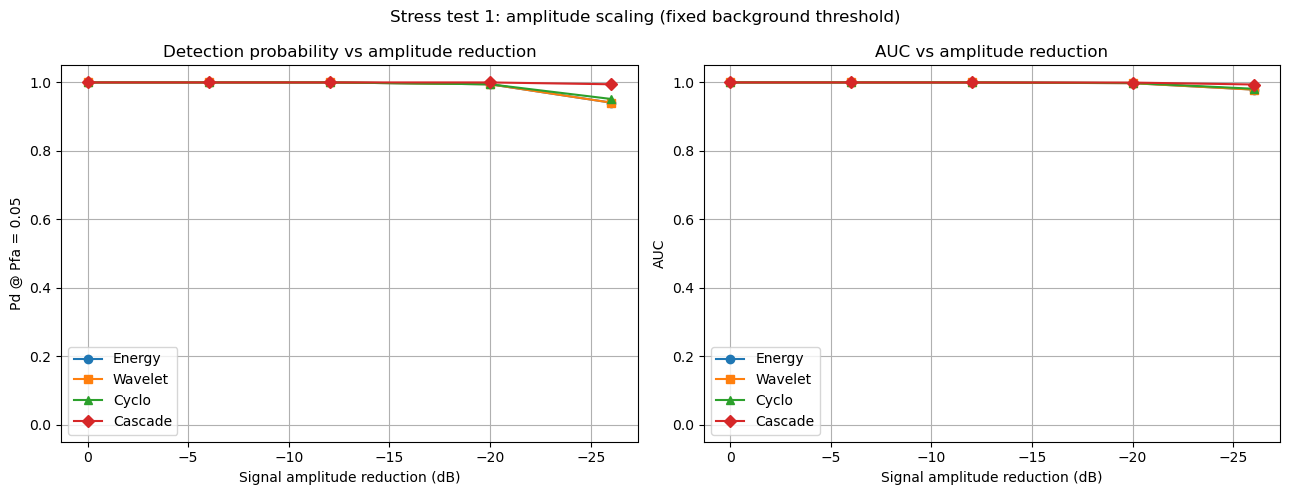

Saved: /home/ivan/work/ml/rfml-uav/results/review_1/stress_amplitude.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
db_vals = df_alpha["db_reduction"].values

for method in METHODS:
    axes[0].plot(db_vals, df_alpha[f"{method}_Pd"],
                 marker=MARKERS[method], color=COLORS[method], label=method)
    axes[1].plot(db_vals, df_alpha[f"{method}_AUC"],
                 marker=MARKERS[method], color=COLORS[method], label=method)

for ax, ylabel, title in zip(axes,
    ["Pd @ Pfa = 0.05", "AUC"],
    ["Detection probability vs amplitude reduction", "AUC vs amplitude reduction"]):
    ax.set_xlabel("Signal amplitude reduction (dB)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_ylim(-0.05, 1.05)
    ax.invert_xaxis()
    ax.legend()
    ax.grid(True)

fig.suptitle("Stress test 1: amplitude scaling (fixed background threshold)", fontsize=12)
fig.tight_layout()
fig.savefig(OUT / "stress_amplitude.png", dpi=150)
plt.show()
print(f"Saved: {OUT / 'stress_amplitude.png'}")

---
## Experiment 2 — Duty Cycle Masking (Intermittent Transmission)

Each signal chunk is independently kept (Bernoulli with p = duty cycle) or zeroed.
At low duty cycle, consecutive active runs are short → few or no bursts ≥ mbl=50.

| Duty cycle | Expected mean consecutive run |
|---|---|
| 100% | sustained (original) |
| 50% | ~2 chunks |
| 25% | ~1.3 chunks |
| 10% | ~1.1 chunks |

**Expected runtime: ~30 min**

In [6]:
DUTY_CYCLE_VALS = [1.0, 0.5, 0.25, 0.10]
dc_records = []

for dc in DUTY_CYCLE_VALS:
    print(f"\nDuty cycle = {dc*100:.0f}%")
    rng = np.random.default_rng(seed=42)  # reset per sweep value for reproducibility

    def dc_transform(chunks, _dc=dc, _rng=rng):
        mask = _rng.random(len(chunks)) < _dc
        out = chunks.copy()
        out[~mask] = 0.0
        return out

    results = evaluate_with_transform(
        transform_fn=dc_transform,
        thr=thr_energy, mbl=FIXED_MBL, nfft=FIXED_NFFT,
        desc=f"dc={dc*100:.0f}%",
    )
    for method, m in results.items():
        print(f"  {method:10s}: Pd={m['Pd']:.3f}  AUC={m['AUC']:.3f}")

    dc_records.append(build_row("duty_cycle", dc, results))

df_dc = pd.DataFrame(dc_records)
df_dc["duty_cycle_pct"] = df_dc["duty_cycle"] * 100
df_dc.to_csv(OUT / "stress_duty_cycle.csv", index=False)
print(f"\nSaved: {OUT / 'stress_duty_cycle.csv'}")
print(df_dc.to_string(index=False))


Duty cycle = 100%


dc=100%: 100%|██████████| 10/10 [12:10<00:00, 73.01s/it]


  Energy    : Pd=1.000  AUC=1.000
  Wavelet   : Pd=1.000  AUC=1.000
  Cyclo     : Pd=1.000  AUC=1.000
  Cascade   : Pd=1.000  AUC=1.000

Duty cycle = 50%


dc=50%: 100%|██████████| 10/10 [09:09<00:00, 54.96s/it]


  Energy    : Pd=1.000  AUC=1.000
  Wavelet   : Pd=1.000  AUC=1.000
  Cyclo     : Pd=1.000  AUC=1.000
  Cascade   : Pd=0.000  AUC=0.488

Duty cycle = 25%


dc=25%: 100%|██████████| 10/10 [09:08<00:00, 54.89s/it]


  Energy    : Pd=1.000  AUC=1.000
  Wavelet   : Pd=1.000  AUC=1.000
  Cyclo     : Pd=1.000  AUC=1.000
  Cascade   : Pd=0.000  AUC=0.488

Duty cycle = 10%


dc=10%: 100%|██████████| 10/10 [09:08<00:00, 54.81s/it]

  Energy    : Pd=1.000  AUC=1.000
  Wavelet   : Pd=1.000  AUC=1.000
  Cyclo     : Pd=1.000  AUC=1.000
  Cascade   : Pd=0.000  AUC=0.488

Saved: /home/ivan/work/ml/rfml-uav/results/review_1/stress_duty_cycle.csv
 duty_cycle  Energy_Pd  Energy_AUC  Wavelet_Pd  Wavelet_AUC  Cyclo_Pd  Cyclo_AUC  Cascade_Pd  Cascade_AUC  duty_cycle_pct
       1.00        1.0         1.0         1.0          1.0       1.0        1.0         1.0     1.000000           100.0
       0.50        1.0         1.0         1.0          1.0       1.0        1.0         0.0     0.487805            50.0
       0.25        1.0         1.0         1.0          1.0       1.0        1.0         0.0     0.487805            25.0
       0.10        1.0         1.0         1.0          1.0       1.0        1.0         0.0     0.487805            10.0


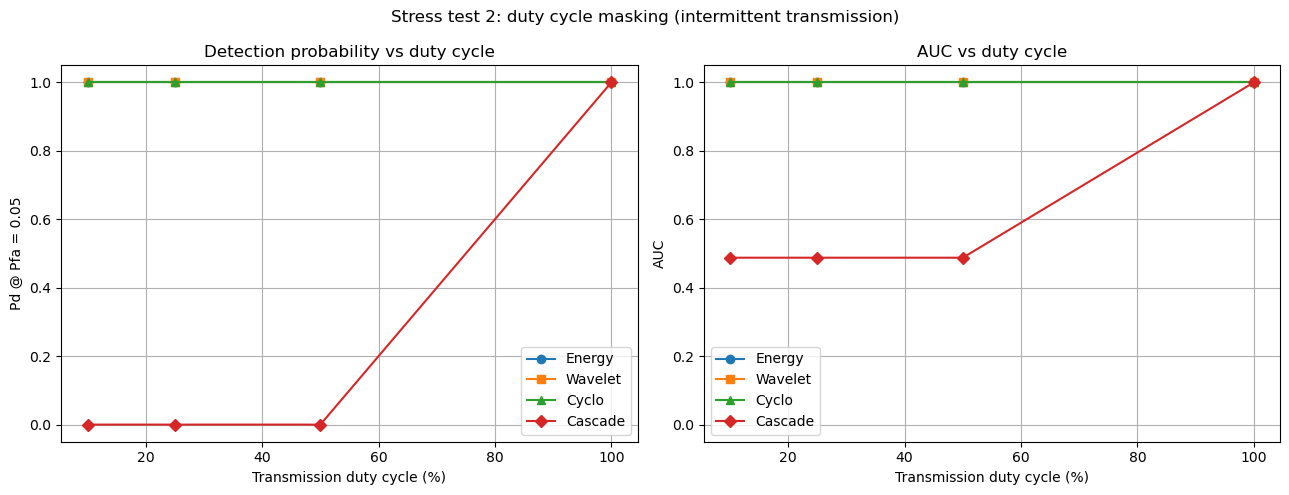

Saved: /home/ivan/work/ml/rfml-uav/results/review_1/stress_duty_cycle.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
dc_pct = df_dc["duty_cycle_pct"].values

for method in METHODS:
    axes[0].plot(dc_pct, df_dc[f"{method}_Pd"],
                 marker=MARKERS[method], color=COLORS[method], label=method)
    axes[1].plot(dc_pct, df_dc[f"{method}_AUC"],
                 marker=MARKERS[method], color=COLORS[method], label=method)

for ax, ylabel, title in zip(axes,
    ["Pd @ Pfa = 0.05", "AUC"],
    ["Detection probability vs duty cycle", "AUC vs duty cycle"]):
    ax.set_xlabel("Transmission duty cycle (%)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_ylim(-0.05, 1.05)
    ax.legend()
    ax.grid(True)

fig.suptitle("Stress test 2: duty cycle masking (intermittent transmission)", fontsize=12)
fig.tight_layout()
fig.savefig(OUT / "stress_duty_cycle.png", dpi=150)
plt.show()
print(f"Saved: {OUT / 'stress_duty_cycle.png'}")

---
## Combined summary figure (for paper)

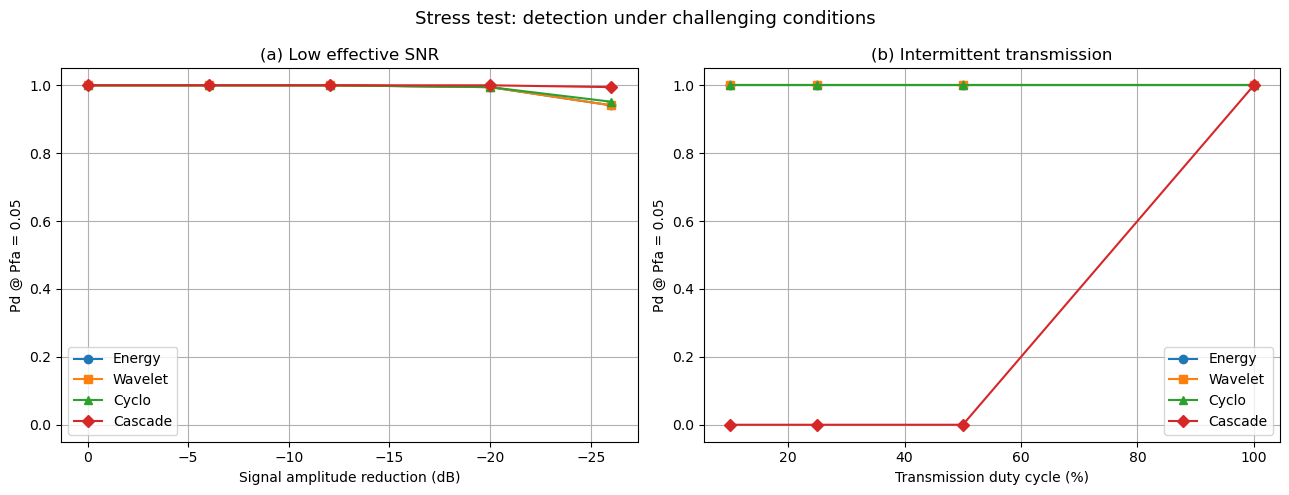

Saved: /home/ivan/work/ml/rfml-uav/results/review_1/stress_combined.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
for method in METHODS:
    ax.plot(df_alpha["db_reduction"], df_alpha[f"{method}_Pd"],
            marker=MARKERS[method], color=COLORS[method], label=method)
ax.set_xlabel("Signal amplitude reduction (dB)")
ax.set_ylabel("Pd @ Pfa = 0.05")
ax.set_title("(a) Low effective SNR")
ax.set_ylim(-0.05, 1.05)
ax.invert_xaxis()
ax.legend()
ax.grid(True)

ax = axes[1]
for method in METHODS:
    ax.plot(df_dc["duty_cycle_pct"], df_dc[f"{method}_Pd"],
            marker=MARKERS[method], color=COLORS[method], label=method)
ax.set_xlabel("Transmission duty cycle (%)")
ax.set_ylabel("Pd @ Pfa = 0.05")
ax.set_title("(b) Intermittent transmission")
ax.set_ylim(-0.05, 1.05)
ax.legend()
ax.grid(True)

fig.suptitle("Stress test: detection under challenging conditions", fontsize=13)
fig.tight_layout()
fig.savefig(OUT / "stress_combined.png", dpi=150)
plt.show()
print(f"Saved: {OUT / 'stress_combined.png'}")

---
## Interpretation notes (for paper Section 4 / 6)

### Amplitude scaling
The cascade's Stage 1 (energy detection) acts as an **SNR gate**. When signal amplitude
drops below the energy threshold, Stage 1 returns no detections and the cascade score is 0.
Standalone cyclostationary detection (which has no gate) continues to accumulate SCF evidence
across all chunks and degrades more gradually. This is a known design trade-off: the cascade
prioritises computational efficiency at the cost of operating range — it is designed for
environments where the signal, when present, exceeds the energy threshold.

### Duty cycle masking
The cascade requires ≥ `min_burst_len` = 50 consecutive active chunks to form a burst and
invoke cyclostationary analysis. UAV RC link signals are characterised by **sustained
transmissions** (continuous DSSS or OFDM), which the DroneRF dataset reflects. At reduced
duty cycle the cascade degrades because its burst aggregation assumption breaks down.
Energy and wavelet detectors, which operate chunk-by-chunk, degrade more gracefully.

**Conclusion for paper:** Both experiments confirm the cascade is optimised for the
high-SNR, sustained-transmission regime that UAV RC links occupy. In environments with
weaker or highly intermittent signals, Stage 1 alone (energy) or standalone cyclostationary
detection would be preferred. This is an explicit scope statement, not a fundamental
limitation.

### Limitation statement (Section 6)
> Stress tests are synthetic: amplitude scaling and duty-cycle masking are applied
> post-chunking to DroneRF data, so preprocessing effects at low SNR are not captured.
> Evaluation on purpose-collected low-SNR or intermittent UAV RF data remains future work.